# Исследование данных о качестве вина

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('../data/winequality-red.csv', sep = ";", encoding="utf-8")

In [3]:
df.head(20)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
(df["free sulfur dioxide"] % 1 == 0).all()

np.False_

In [6]:
(df["total sulfur dioxide"] % 1 == 0).all()

np.False_

**Вывод:**
- Пропущенных значений нет;
- Все данные имеют корректный формат.

In [7]:
df.duplicated().sum()

np.int64(240)

Необходимо удалить дубликаты

In [8]:
df_filtered = df.drop_duplicates()

## Визуальный анализ данных

In [9]:
df_filtered.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


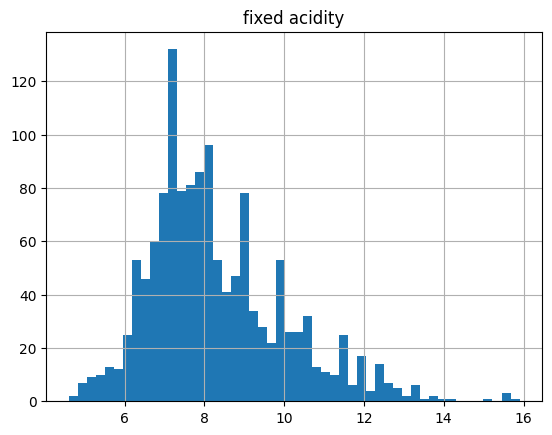

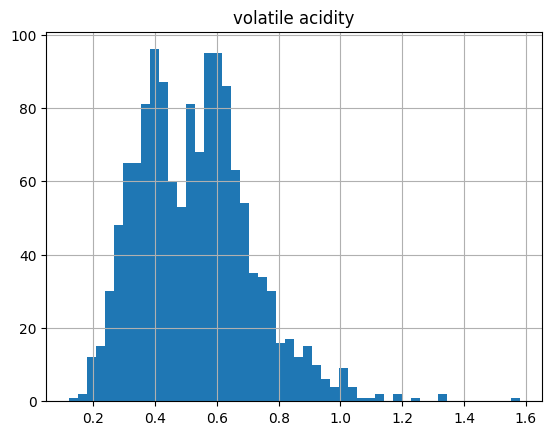

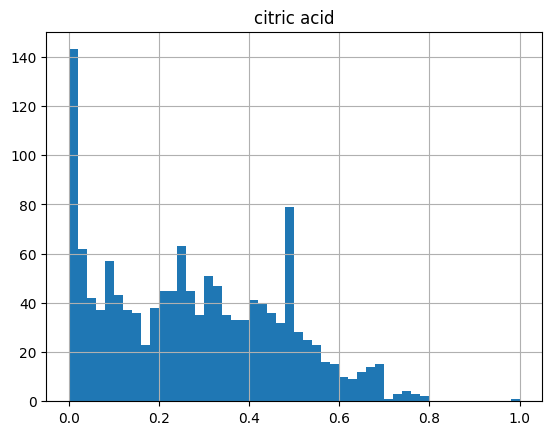

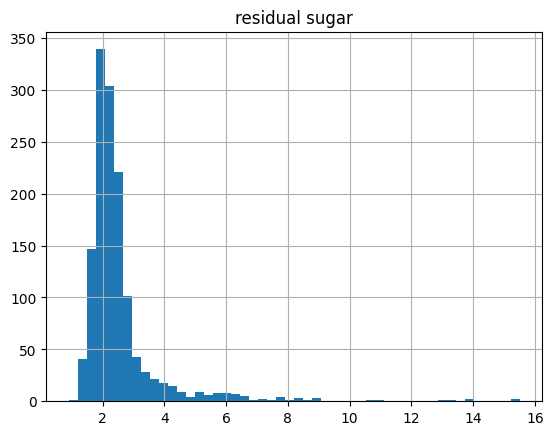

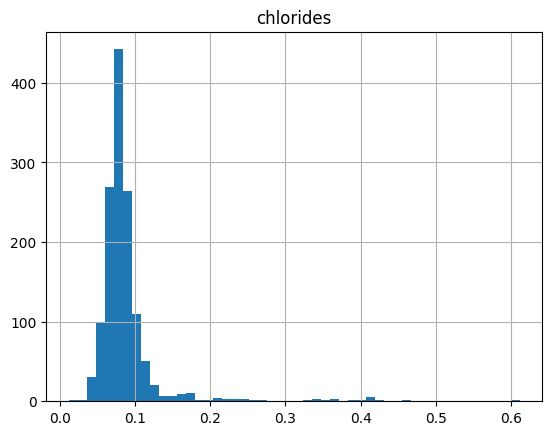

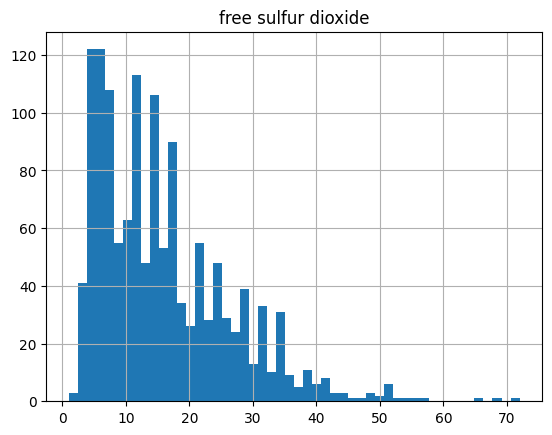

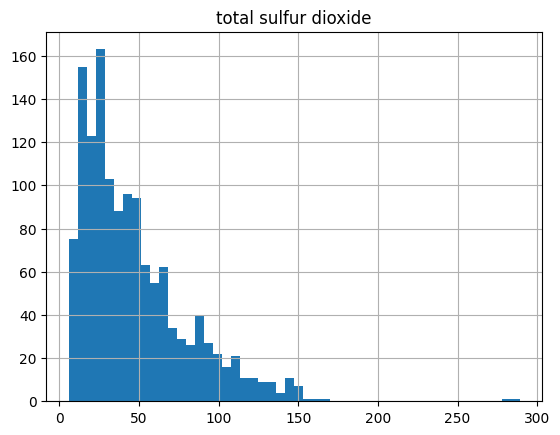

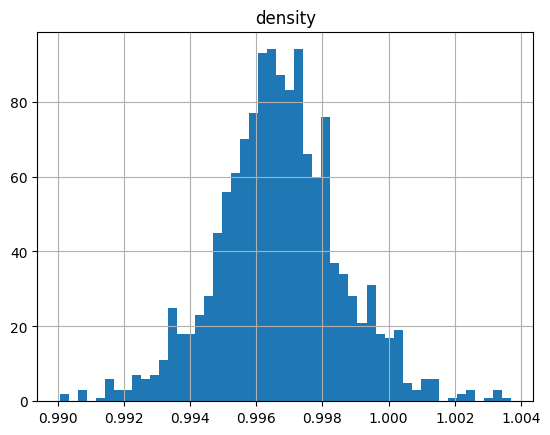

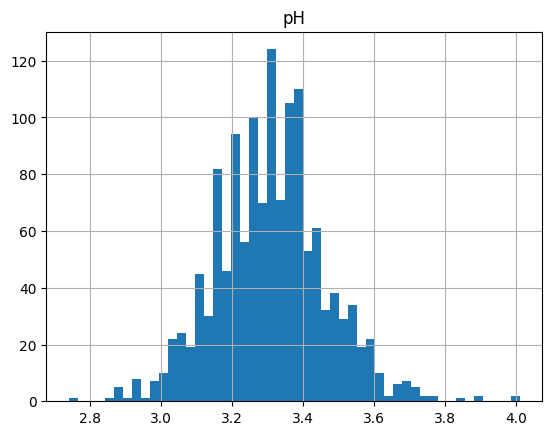

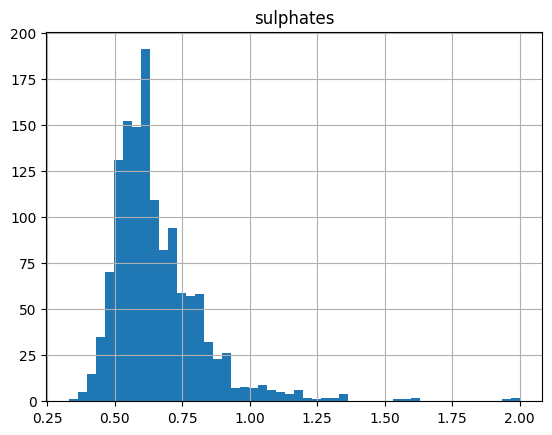

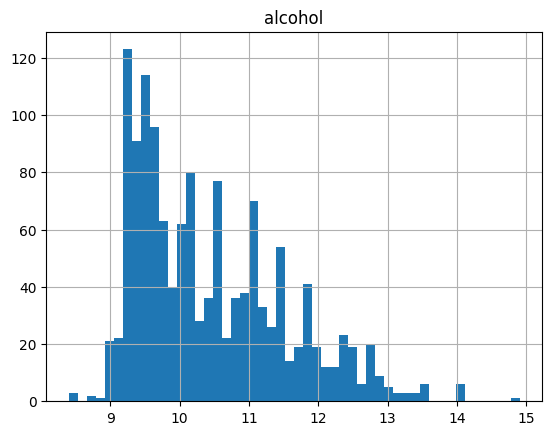

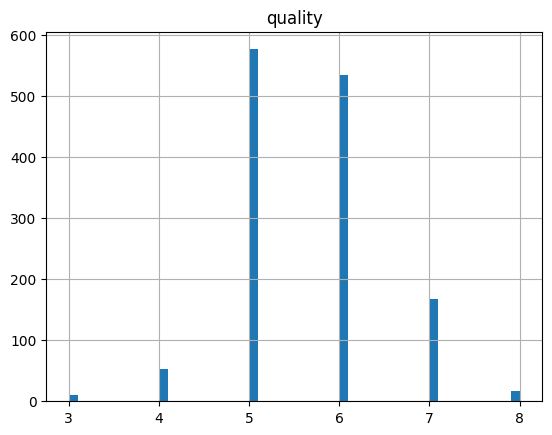

In [10]:
columns = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates", "alcohol", "quality"]

for column in columns:
    df_filtered.hist(column, bins=50)

**Выводы:**

- Все параметры, кроме "citrit axid" имеют график, напоминающий нормальное распределение;
- Гистограммы параметров "sulphates", "total sulfur dioxide", "chlorides" и "residental sugar" смещены вправо, что затрудняет чтение данных.

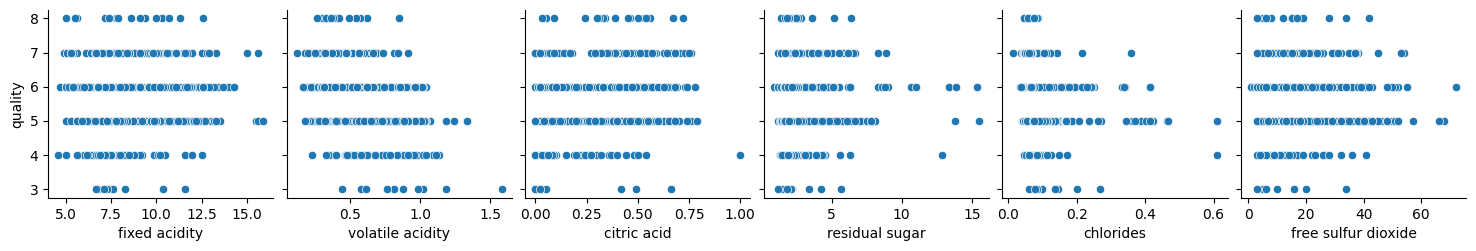

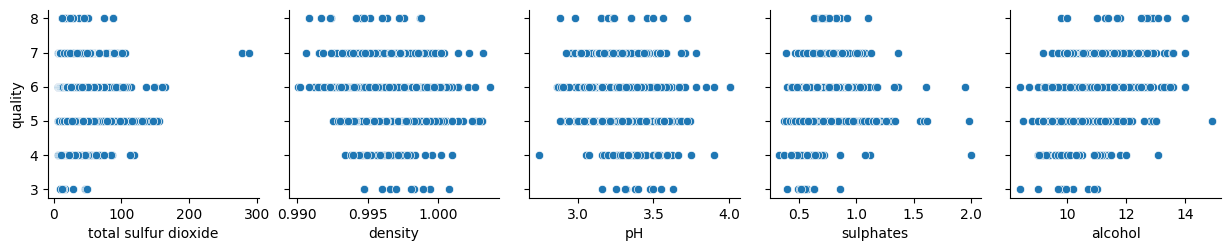

In [11]:
sns.pairplot(df_filtered, y_vars=["quality"], x_vars=["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"])
sns.pairplot(df_filtered, y_vars=["quality"], x_vars=["total sulfur dioxide", "density", "pH", "sulphates", "alcohol"])

<Axes: >

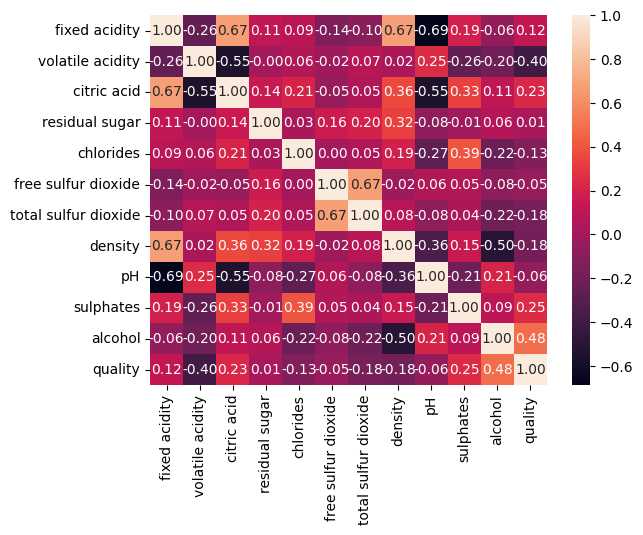

In [12]:
sns.heatmap(df_filtered.corr(), annot = True, fmt = '.2f')

**Выводы:**

- Очевидна связь с содержанием алкоголя и качеством
- С алкоголем отрицательная корреляция у плотности (что логично, ведь плотность спирта меньше плотности воды)
- Видна обратная связь с "volatile acidity" и качеством
- С "volatile acidity" обратно коррелирует "citric acid" (возможно, содержание лимонной кислоты косвенно влияет на качество в лучшую сторону)

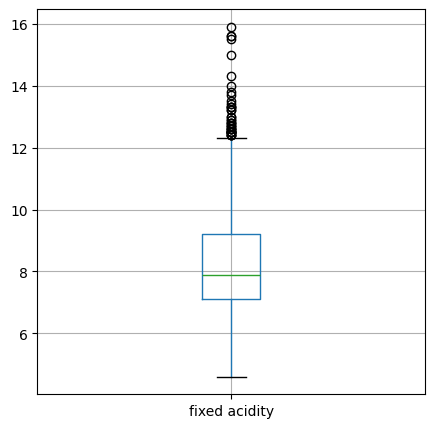

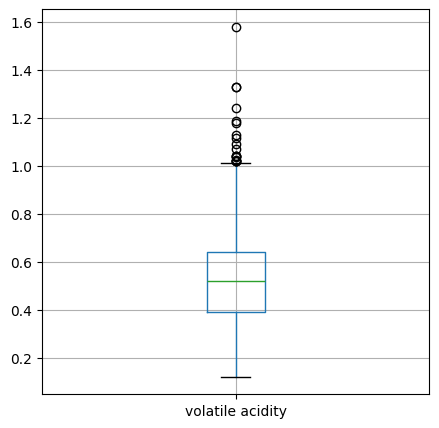

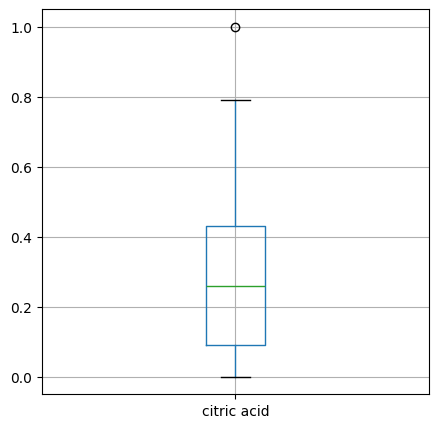

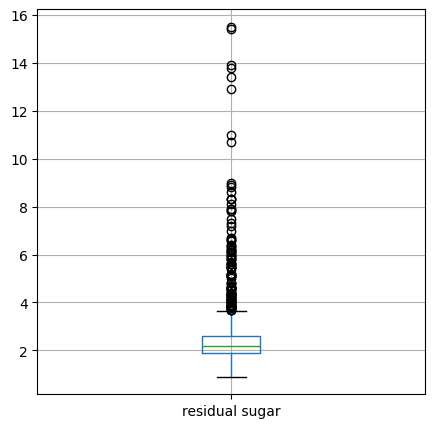

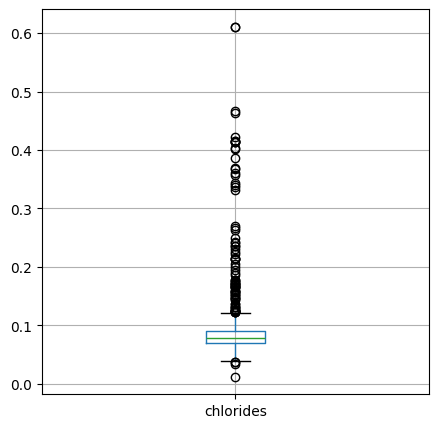

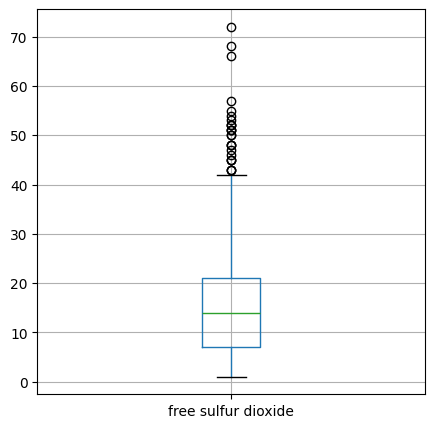

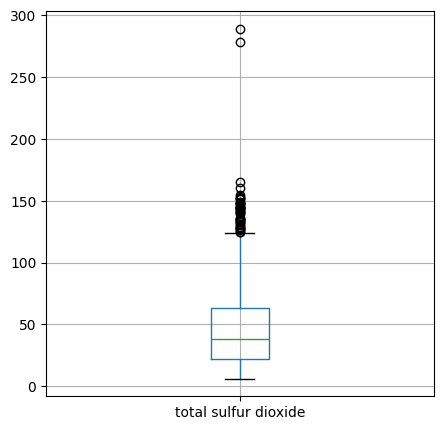

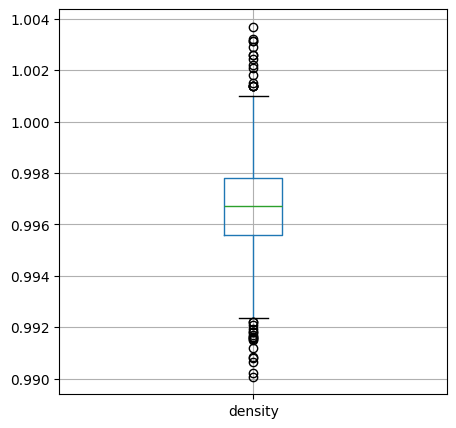

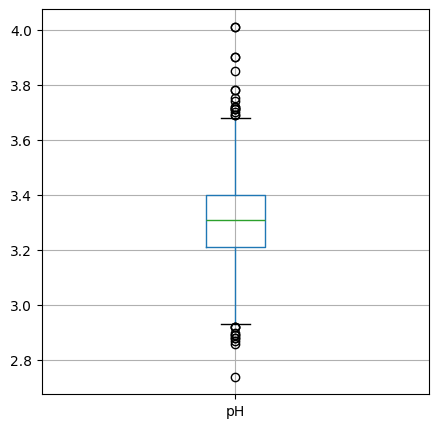

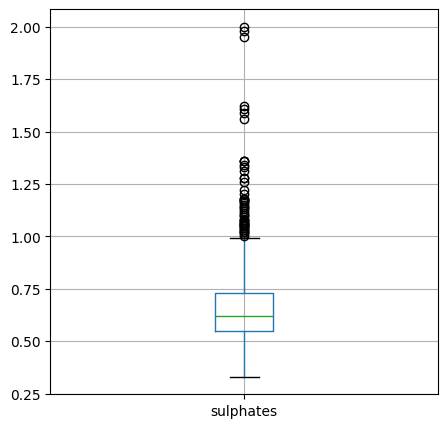

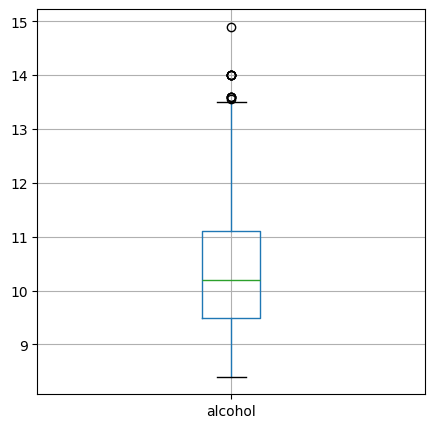

In [13]:
columns = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates", "alcohol"]

for column in columns:
    plt.figure(figsize=(5, 5))
    df_filtered.boxplot(column)
    plt.show()

**Вывод:**

- Видно много выбросов почти по всем параметрам, кроме "alochol" и "citric acid"

In [14]:
df.to_csv("../data/Regression_wine_quality_filtered.csv")